In [1]:
import sys
import math
import numpy as np
import scipy
import matplotlib.pyplot as plt

sys.path.append('..')
from src.kernels import exp_kernel, complex_exp_kernel, complex_discrete_kernel
from src.probability import Distribution
from src.spectral_transforms import psi_real_to_circle, psi_inv_circle_to_real, B_real, B_circle
from src.numerical import trap_quad, fourier_quad, conv_trap, conv_fourier, volterra_cm_numerical_inversion, volterra_pd_numerical_inversion
from src.plotting import plot_real_distribution, plot_discrete

plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=8)
plt.rcParams.update({
    'font.size': 8,
    'text.usetex': True,
    'text.latex.preamble': r"\usepackage{amsfonts}" + "\n" + r"\usepackage{amsmath}" + "\n" + r"\usepackage{amssymb}"
})

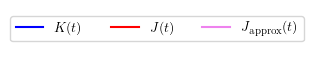

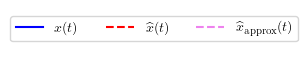

In [6]:
fig, ax = plt.subplots(figsize=(2, 0.5))

# Create empty lines with labels
ax.plot([], [], color="blue")
ax.plot([], [], color="red")
ax.plot([], [], color="violet")
ax.axis('off')

# Create the legend
plt.legend(["$K(t)$", "$J(t)$", "$J_{\mathrm{approx}}(t)$"], bbox_to_anchor=[0.5, 0.5], loc='center', fontsize=10, ncol=4)

plt.savefig('../figures/dirac_kernel_legend.pdf', bbox_inches='tight', pad_inches=0.1)


fig, ax = plt.subplots(figsize=(2, 0.5))

# Create empty lines with labels
ax.plot([], [], color="blue")
ax.plot([], [], color="red", linestyle="--")
ax.plot([], [], color="violet", linestyle='--')
ax.axis('off')

# Create the legend
plt.legend(["$x(t)$", "$\widehat{x}(t)$", "$\widehat{x}_{\mathrm{approx}}(t)$"], bbox_to_anchor=[0.5, 0.5], loc='center', fontsize=10, ncol=4)

plt.savefig('../figures/dirac_data_legend.pdf', bbox_inches='tight', pad_inches=0.1)

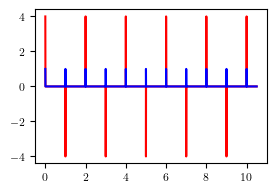

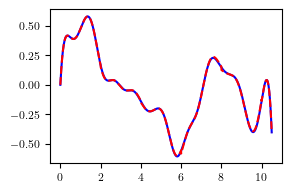

In [11]:
c1 = 0

T = 10.5
t = np.linspace(0, T, 10000)
dt = t[1] - t[0]

n_interp = 20
np.random.seed(3)
interp_xs = np.cumsum(np.insert(np.random.randn(n_interp), 0, 0))/np.sqrt(n_interp)
interp_ts = np.linspace(0, T, n_interp+1)
cs = scipy.interpolate.make_interp_spline(interp_ts, interp_xs, k=5)
x = cs(t)
xdot = np.gradient(x, t)

# Define Volterra equation kernel and coefficients
K = np.zeros_like(t)
for i in range(len(t)):
    ind = np.abs(t-i).argmin()
    if np.abs(t[ind]-i) < 1e-1:
        K[ind] = 1

y = c1*xdot + conv_fourier(K, x, t, sum=True, half_zero=True)

J_analytic = np.zeros_like(t)
for i in range(len(t)):
    ind = np.abs(t-i).argmin()
    if np.abs(t[ind]-i) < 1e-1:
        J_analytic[ind] = 4*np.pi**2*(-1)**i

x_analytic = 1/np.pi**2 * conv_fourier(J_analytic, y, t, sum=True, half_zero=True)

rel_err_x = np.linalg.norm(x - x_analytic)/np.linalg.norm(x_analytic)

fig, ax = plt.subplots(figsize=(3, 2))
ax.plot(t, J_analytic/np.pi**2, color="red")
ax.plot(t, K, color="blue")
ax.set_xticks(ticks=np.arange(0, T, 2))
plt.savefig(f"../figures/main_comb_kernel_inversion_c=0.pdf", bbox_inches='tight', pad_inches=0.08)
plt.show()

fig, ax = plt.subplots(figsize=(3, 2))
ax.plot(t, x, color="blue", zorder=1)
#ax.plot(t, y, color="red")
ax.plot(t, x_analytic, linestyle='--', color="red")
#ax.set_title(f"Rel. Err. = {rel_err_x:.3e}", size=10)
ax.set_xticks(ticks=np.arange(0, T, 2))
plt.savefig(f"../figures/main_comb_data_inversion_c=0.pdf", bbox_inches='tight', pad_inches=0.08)
plt.show()

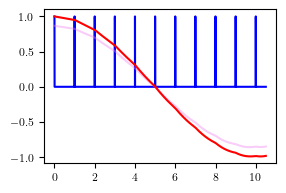

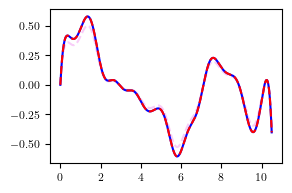

In [22]:
c1 = 10

T = 10.5
t = np.linspace(0, T, 10000)
dt = t[1] - t[0]

n_interp = 20
np.random.seed(3)
interp_xs = np.cumsum(np.insert(np.random.randn(n_interp), 0, 0))/np.sqrt(n_interp)
interp_ts = np.linspace(0, T, n_interp+1)
cs = scipy.interpolate.make_interp_spline(interp_ts, interp_xs, k=5)
x = cs(t)
xdot = np.gradient(x, t)

# Define Volterra equation kernel and coefficients
K = np.zeros_like(t)
for i in range(len(t)):
    ind = np.abs(t-i).argmin()
    if np.abs(t[ind]-i) < 1e-1:
        K[ind] = 1

y = c1*xdot + conv_fourier(K, x, t, sum=True, half_zero=True)

density = None
n_ints = 1000
xmin, xmax = -n_ints*2*np.pi, n_ints*2*np.pi
f = lambda x: 1/np.tan(x/2) - 2*c1*x
atoms = np.zeros(2*n_ints)
from src.hilbert_transform import rescale_rootfind
for i in range(2*n_ints):
    atoms[i] = rescale_rootfind(f, (xmin + i*2*np.pi, xmin + (i+1)*2*np.pi), root_tol=1e-15)
atom_wts = np.zeros(2*n_ints)
for i in range(2*n_ints):
    atom_wts[i] = np.pi**2/(c1 + np.sum(1/(2*np.pi*np.arange(-10000, 10001) - (atoms[i] % (2*np.pi)))**2))
quad_pts, quad_wts = trap_quad(-10, 10, int(1e5))
mu = Distribution(density, atoms, atom_wts, quad_pts, quad_wts)
J_analytic = complex_exp_kernel(mu, t)

js = np.concatenate((np.arange(-1000, 0), np.arange(1, 1001)))
atoms = np.concatenate(([1/np.sqrt(c1), -1/np.sqrt(c1)], 2*np.pi*js + 1/(2*np.pi*js*c1)))
atom_wts = np.concatenate((2*[np.pi**2/(2*c1+np.pi**2/3)], np.pi**2/(c1 + 4*np.pi**2*js**2*c1**2)))
mu_asymp = Distribution(density, atoms, atom_wts, quad_pts, quad_wts)
J_asymp = complex_exp_kernel(mu_asymp, t)

x_asymp = 1/np.pi**2 * conv_trap(J_asymp, y, t)
x_analytic = 1/np.pi**2 * conv_trap(J_analytic, y, t)

rel_err_x_asymp = np.linalg.norm(x - x_asymp)/np.linalg.norm(x)
rel_err_x_analytic = np.linalg.norm(x - x_analytic)/np.linalg.norm(x)

fig, ax = plt.subplots(figsize=(3, 2))
ax.plot(t, K, color="blue")
ax.plot(t, J_asymp*c1/np.pi**2, color="violet", alpha=0.4)
ax.plot(t, J_analytic*c1/np.pi**2, color="red")
ax.set_xticks(ticks=np.arange(0, T, 2))
plt.savefig(f"../figures/main_comb_kernel_inversion_c={c1}.pdf", bbox_inches='tight', pad_inches=0.08)
plt.show()

fig, ax = plt.subplots(figsize=(3, 2))
ax.plot(t, x_asymp, linestyle='--', color="violet", alpha=0.4)
ax.plot(t, x, color="blue")
ax.plot(t, x_analytic, linestyle='--', color="red")
#ax.set_title(f"Rel. Err. = {rel_err_x:.3e}", size=10)
ax.set_xticks(ticks=np.arange(0, T, 2))
plt.savefig(f"../figures/main_comb_data_inversion_c={c1}.pdf", bbox_inches='tight', pad_inches=0.08)
plt.show()